# E2: Multi-entrance corridor navigation with Gaussian-mixture initial law

This notebook extends E1 (density-level corridor optimization with deterministic
start) to a **Gaussian-mixture initial distribution**.  Two entrance modes are
placed above and below the corridor axis, creating a "funneling" transport
problem where both modes must be steered through the same S-shaped corridor
to the same bimodal terminal target.

## Key advance over E1

- The initial condition is a 2-component GMM (not a delta function).
- The shared corridor and target from E1 are reused, so the reader sees
  exactly what changes when the start goes from point mass to distribution.

## Implementation: sample at $t=0$, exact conditional evolution for $t > 0$

The procedure mirrors what happens in a real simulation:

1. **Sample** $B$ particles $\{x_0^{(n)}\}_{n=1}^B$ from $p^{(\mathrm{in})}$
   **once** (fixed across all optimization iterations).
2. For each $x_0^{(n)}$, compute the **exact conditional marginal**
   $p_t^*(x \mid x_0^{(n)})$ using the closed-form GMM formulas. This is a
   $M_{\mathrm{tar}}$-component GMM — no Euler–Maruyama, no discretization error.
3. The corridor alignment is the **particle average**:
   $$\mathcal{A}_k \approx \frac{1}{B}\sum_{n=1}^B
     \mathbb{E}_{p_t(\cdot \mid x_0^{(n)})}[K_k(x)],$$
   where each expectation is a closed-form sum over $M_{\mathrm{tar}}$ Gaussians.

**Sampling is only at $t = 0$.** Everything after that — marginals, corridor
alignment, gradients — is exact and deterministic.  The only stochasticity
is in the initial draw, which is fixed once and reused.

The forward sweep uses the standard delta BC (each particle is a point).
The quadratic coefficients $(A_t^+, B_t^+, C_t^+)$ are shared across all
particles; only the linear terms differ via $B_t^+ x_0^{(n)}$ products.

## Diagnostic figures

Same five-figure suite as E1, plus a sixth figure zooming into the
entrance-merging phase ($t \in [0, 0.25]$).  The marginal shown at each
time is the $B$-particle mixture of conditional GMMs.

In [1]:
from __future__ import annotations

import math
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import torch

if "__file__" in globals():
    ROOT = Path(__file__).resolve().parents[1]
else:
    ROOT = Path.cwd().resolve()
    if not (ROOT / "lqgm_pid").exists():
        for parent in [ROOT] + list(ROOT.parents):
            if (parent / "lqgm_pid").exists():
                ROOT = parent
                break

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.common import (
    ensure_dir,
    set_seed,
    default_device,
    default_dtype,
    save_metrics_json,
)
from lqgm_pid import (
    GaussianMixture, MatrixPWCProtocol, TimeDomain, LQGMPID,
    gmm_control, backward_sweep, forward_sweep,
)
from lqgm_pid.density import exact_marginal_gmm
from lqgm_pid.control import eval_bwd, eval_fwd

## Configuration

All corridor/target geometry is **identical to E1**.  The new parameters
control the initial GMM (entrance positions and widths).

In [2]:
SEED = 42
DEVICE = default_device()
DTYPE = default_dtype()

OUTDIR = ensure_dir(str(ROOT / "results" / "E2_multi_entrance"))
FIGDIR = ensure_dir(str(ROOT / "figs"))

# Protocol
K = 10
BC_EPS = 1e-6
TD_EPS = 1e-3

# Optimization
N_ITERS = 300
LR = 3e-2
PRINT_EVERY = 20

# Corridor window
T_CORR_STAR = 0.80

# Weights (same as E1)
LAMBDA_CORR = 10.0
LAMBDA_RHO = 0.10
LAMBDA_BETA = 0.05

# Corridor geometry (same as E1)
SWING_AMPLITUDE = 0.70
SWING_KAPPA = 6.0

# Stiffnesses (same as E1)
BETA_LONG_FIXED = 0.2
BETA_PERP_INIT = 15.0
BETA_PERP_MIN = 2.0
BETA_PERP_MAX = 60.0
BETA_PERP_BASELINE = 3.0

# Gaussian corridor kernel (same as E1)
OMEGA_LONG = 0.80
OMEGA_PERP = 0.20

# --- NEW: initial GMM parameters ---
X_ENTRY = -0.3          # longitudinal position of entrance ports
DELTA_Y = 0.50          # transverse half-separation between entrance modes
SIGMA_0 = 0.12          # initial mode standard deviation (isotropic)
B_INIT = 60             # number of particles sampled from initial GMM (fixed once)

# EM simulation for scatter plots
N_STEPS_EM = 200        # Euler–Maruyama time steps for visualization
B_SIM = 200             # total EM particles for scatter plots

# Snapshot times
SNAPSHOT_TIMES = [0.00, 0.12, 0.25, 0.38, 0.50, 0.62, 0.75, 0.88, 1.00]
MERGE_TIMES = [0.00, 0.04, 0.08, 0.12, 0.16, 0.20, 0.25]

# Visualization
XLIM = (-1.0, 3.8)
YLIM = (-1.6, 1.6)
NGRID_DENSITY = 120
NGRID_SCORE = 18

set_seed(SEED)
print(f"Device: {DEVICE}")

Device: cpu


## Geometry helpers (identical to E1)

In [3]:
def _normalize_rows(x, eps=1e-12):
    return x / torch.linalg.norm(x, dim=-1, keepdim=True).clamp_min(eps)

def _fd_tangent(xy):
    dx = torch.zeros_like(xy)
    dx[1:-1] = 0.5 * (xy[2:] - xy[:-2])
    dx[0] = xy[1] - xy[0]
    dx[-1] = xy[-1] - xy[-2]
    return _normalize_rows(dx)

def _match_to_grid(query_t, grid_t):
    return torch.argmin(torch.abs(query_t.unsqueeze(-1) - grid_t.unsqueeze(0)), dim=-1)

## Corridor midline (identical to E1)

In [4]:
def make_s_corridor(s_grid, *, x_end=3.0, A=SWING_AMPLITUDE, kappa=SWING_KAPPA):
    s = s_grid
    x = x_end * s
    y = A * torch.tanh(kappa * (s - 0.30)) - A * torch.tanh(kappa * (s - 0.70))
    y = y - y[0] - (y[-1] - y[0]) * s
    xy = torch.stack([x, y], dim=-1)
    tangent = _fd_tangent(xy)
    normal = torch.stack([-tangent[:, 1], tangent[:, 0]], dim=-1)
    return {"s": s, "xy": xy, "tangent": tangent, "normal": normal}

def sample_corridor_at(corridor, s_k):
    idx = _match_to_grid(s_k, corridor["s"])
    return {k: corridor[k][idx] for k in ["xy", "tangent", "normal"]}

## Target GMM (identical to E1)

In [5]:
def make_target(dtype=DTYPE, device=DEVICE):
    weights = torch.tensor([0.5, 0.5], dtype=dtype, device=device)
    means = torch.tensor([[3.0, 0.50], [3.0, -0.50]], dtype=dtype, device=device)
    cov = torch.tensor([[0.06, 0.00], [0.00, 0.05]], dtype=dtype, device=device)
    covs = torch.stack([cov, cov], dim=0)
    return GaussianMixture(weights=weights, means=means, covs=covs)

## Initial GMM

Two entrance modes placed symmetrically above and below the corridor axis,
slightly behind the corridor entry point:
$$p^{(\mathrm{in})}(x) = \tfrac{1}{2}\,\mathcal{N}\bigl(x;\,(x_{\mathrm{entry}},+\delta_y),\,\sigma_0^2 I\bigr) + \tfrac{1}{2}\,\mathcal{N}\bigl(x;\,(x_{\mathrm{entry}},-\delta_y),\,\sigma_0^2 I\bigr).$$

In [6]:
def make_initial_gmm(dtype=DTYPE, device=DEVICE):
    weights = torch.tensor([0.5, 0.5], dtype=dtype, device=device)
    means = torch.tensor([
        [X_ENTRY,  DELTA_Y],
        [X_ENTRY, -DELTA_Y],
    ], dtype=dtype, device=device)
    cov = SIGMA_0**2 * torch.eye(2, dtype=dtype, device=device)
    covs = torch.stack([cov, cov], dim=0)
    return GaussianMixture(weights=weights, means=means, covs=covs)

## Protocol builders (identical to E1)

In [7]:
def make_breaks(K, dtype=DTYPE, device=DEVICE):
    return torch.linspace(0.0, 1.0, K + 1, dtype=dtype, device=device)

def s_midpoints(K, dtype=DTYPE, device=DEVICE):
    breaks = make_breaks(K, dtype=dtype, device=device)
    return 0.5 * (breaks[:-1] + breaks[1:])

def build_baseline_protocol(corridor, s_k, breaks):
    geom = sample_corridor_at(corridor, s_k)
    K = s_k.numel()
    nu = geom["xy"].clone()
    beta = BETA_PERP_BASELINE * torch.eye(2, dtype=DTYPE, device=DEVICE).unsqueeze(0).expand(K, -1, -1).clone()
    sigma = torch.zeros(K, 2, 2, dtype=DTYPE, device=DEVICE)
    protocol = MatrixPWCProtocol(breaks=breaks, sigma=sigma, beta=beta, nu=nu,
                                  time_domain=TimeDomain(eps=TD_EPS))
    return protocol, {"nu": nu, "m": geom["xy"], **geom}

## Trainable protocol state (identical to E1)

- $\rho_k$: transverse guide offset from corridor midline.
- $c_k$: unconstrained parameter, mapped to $\beta_k^{(\perp)} \in [\beta_{\min}, \beta_{\max}]$ via sigmoid.

In [8]:
@dataclass
class TrainableState:
    rho: torch.nn.Parameter
    c_beta: torch.nn.Parameter

def c_beta_to_beta_perp(c):
    return BETA_PERP_MIN + (BETA_PERP_MAX - BETA_PERP_MIN) * torch.sigmoid(c)

def beta_perp_to_c_beta(bp):
    s = (bp - BETA_PERP_MIN) / (BETA_PERP_MAX - BETA_PERP_MIN)
    s = max(1e-6, min(1.0 - 1e-6, s))
    return math.log(s / (1.0 - s))

def build_trainable_protocol(state, corridor, s_k, breaks):
    geom = sample_corridor_at(corridor, s_k)
    tangent, normal, m_k = geom["tangent"], geom["normal"], geom["xy"]
    K = s_k.numel()
    nu = m_k + state.rho[:, None] * normal
    beta_list = []
    sigma = torch.zeros(K, 2, 2, dtype=DTYPE, device=DEVICE)
    b_long = torch.tensor(BETA_LONG_FIXED, dtype=DTYPE, device=DEVICE)
    for k in range(K):
        R = torch.stack([tangent[k], normal[k]], dim=-1)
        b_perp = c_beta_to_beta_perp(state.c_beta[k])
        D = torch.diag(torch.stack([b_long, b_perp]))
        beta_list.append(R @ D @ R.T)
    beta = torch.stack(beta_list)
    protocol = MatrixPWCProtocol(breaks=breaks, sigma=sigma, beta=beta, nu=nu,
                                  time_domain=TimeDomain(eps=TD_EPS))
    aux = {"nu": nu, "m": m_k, "tangent": tangent, "normal": normal, "beta": beta}
    return protocol, aux

## Exact conditional marginal for sampled initial particles

Given $B$ particles $\{x_0^{(n)}\}_{n=1}^B$ sampled from $p^{(\mathrm{in})}$,
the approximate marginal at time $t$ is

$$p_t(x) \approx \frac{1}{B}\sum_{n=1}^B p_t^*(x \mid x_0^{(n)}),$$

where each $p_t^*(x \mid x_0^{(n)})$ is an $M_{\mathrm{tar}}$-component GMM
computed via the standard ratio-form formulas.  This gives a
$B \times M_{\mathrm{tar}}$-component GMM with uniform weights $1/B$.

### Efficient computation

The quadratic coefficients $(A_t^\pm, B_t^\pm, C_t^-, S_k, \Lambda_k,
\Pi_k, \Sigma_k)$ are **independent of $x_0$** and computed once (using the
standard delta-BC forward sweep).  For each particle $x_0^{(n)}$, only two
matrix-vector products are needed: $B_1^+ x_0^{(n)}$ and $B_t^+ x_0^{(n)}$.

### Corridor loss

The alignment is a **particle average** of per-particle closed-form scores:

$$\mathcal{A}_k \approx \frac{1}{B}\sum_{n=1}^B
  \sum_{m=1}^{M_{\mathrm{tar}}} \bar\pi_m^{(n)}(t_k)\,
  \mathcal{A}_k^{(n,m)}.$$

In [9]:
def _shared_marginal_quantities(protocol, target, t, bwd, fwd):
    """Precompute x0-independent quantities for the marginal at time t."""
    dev = protocol.device
    dty = protocol.dtype
    Mtar = target.M
    d = protocol.d

    cs_bwd = eval_bwd(t, bwd, protocol)
    cs_fwd_t = eval_fwd(t, fwd, protocol)
    cs_fwd1 = fwd[protocol.K]

    A_m = cs_bwd.A;  B_m = cs_bwd.B;  C_m = cs_bwd.C
    tx_m = cs_bwd.theta_x;  ty_m = cs_bwd.theta_y
    A_p = cs_fwd_t.A;  B_p = cs_fwd_t.B;  tx_p = cs_fwd_t.theta_x
    A1_p = cs_fwd1.A;  B1_p = cs_fwd1.B;  tx1_p = cs_fwd1.theta_x

    Ps = target.precisions.to(dev, dty)
    ms = target.means.to(dev, dty)
    logpi_tar = torch.log(target.weights.to(dev, dty))

    Sk = C_m.unsqueeze(0) + Ps - A1_p.unsqueeze(0)
    Sk_inv = torch.linalg.inv(Sk)
    Pkm = torch.bmm(Ps, ms.unsqueeze(-1)).squeeze(-1)
    Bm_exp = B_m.unsqueeze(0).expand(Mtar, d, d)
    BSkInv = torch.bmm(Bm_exp, Sk_inv)
    Lambda = A_m.unsqueeze(0) - torch.bmm(BSkInv, Bm_exp.transpose(-2, -1))
    Pi = A_p.unsqueeze(0) + Lambda
    Sigma = torch.linalg.inv(Pi)

    logdet_Sk = torch.logdet(Sk)
    logdet_Pk = torch.logdet(Ps)
    logdet_Pi = torch.logdet(Pi)
    mPkm = torch.einsum('md,md->m', ms, Pkm)

    return {
        "B1_p": B1_p, "tx1_p": tx1_p, "B_p": B_p, "tx_p": tx_p,
        "tx_m": tx_m, "ty_m": ty_m,
        "Sk_inv": Sk_inv, "BSkInv": BSkInv, "Pkm": Pkm,
        "Pi": Pi, "Sigma": Sigma,
        "logpi_tar": logpi_tar, "logdet_Sk": logdet_Sk,
        "logdet_Pk": logdet_Pk, "logdet_Pi": logdet_Pi, "mPkm": mPkm,
    }


def _conditional_marginal_for_x0(x0, shared):
    """Compute the M_tar-component conditional marginal for a single x0.

    Returns (logw, mu, Sigma):
      logw  : (Mtar,)       unnormalized log-weights
      mu    : (Mtar, d)     component means
      Sigma : (Mtar, d, d)  component covariances (x0-independent)
    """
    S = shared
    B1p_x0 = S["B1_p"] @ x0
    qk = S["ty_m"].unsqueeze(0) + S["Pkm"] - B1p_x0.unsqueeze(0) - S["tx1_p"].unsqueeze(0)
    BSkInv_q = torch.bmm(S["BSkInv"], qk.unsqueeze(-1)).squeeze(-1)
    lam_k = S["tx_m"].unsqueeze(0) + BSkInv_q

    Bp_x0 = S["B_p"] @ x0
    rhs = (Bp_x0 + S["tx_p"]).unsqueeze(0) + lam_k
    mu = torch.bmm(S["Sigma"], rhs.unsqueeze(-1)).squeeze(-1)

    Skinv_qk = torch.bmm(S["Sk_inv"], qk.unsqueeze(-1)).squeeze(-1)
    qSinvq = torch.einsum('md,md->m', qk, Skinv_qk)
    Ck = -0.5*S["logdet_Sk"] + 0.5*S["logdet_Pk"] - 0.5*S["mPkm"] + 0.5*qSinvq
    muPimu = torch.einsum('md,md->m', mu, torch.bmm(S["Pi"], mu.unsqueeze(-1)).squeeze(-1))
    logw = S["logpi_tar"] + Ck - 0.5*S["logdet_Pi"] + 0.5*muPimu

    return logw, mu, S["Sigma"]


def marginal_from_samples(
    protocol: MatrixPWCProtocol,
    target: GaussianMixture,
    x0_samples: torch.Tensor,   # (B, d)
    t: float,
    *,
    bc_eps: float = BC_EPS,
    _cache: Optional[Dict] = None,
) -> Dict[str, torch.Tensor]:
    """Assemble the B*M_tar component marginal for plotting.

    Each particle contributes M_tar components with weight 1/B.
    """
    B_samp = x0_samples.shape[0]

    if _cache is not None and "bwd" in _cache:
        bwd, fwd = _cache["bwd"], _cache["fwd"]
    else:
        bwd = backward_sweep(protocol, bc_eps=bc_eps)
        fwd = forward_sweep(protocol, bc_eps=bc_eps)  # standard delta BC
        if _cache is not None:
            _cache["bwd"] = bwd; _cache["fwd"] = fwd

    shared = _shared_marginal_quantities(protocol, target, t, bwd, fwd)

    all_logw, all_mu, all_cov = [], [], []
    log_B = math.log(B_samp)

    for n in range(B_samp):
        logw_n, mu_n, Sigma_n = _conditional_marginal_for_x0(x0_samples[n], shared)
        all_logw.append(logw_n - log_B)
        all_mu.append(mu_n)
        all_cov.append(Sigma_n)

    logw_all = torch.cat(all_logw)
    logw_all = logw_all - torch.logsumexp(logw_all, dim=0)
    return {
        "weights": torch.exp(logw_all),
        "means": torch.cat(all_mu, dim=0),
        "covs": torch.cat(all_cov, dim=0),
    }

## Corridor loss and regularization

The corridor loss averages the per-particle alignment over the $B$ sampled
initial particles.  For each particle $x_0^{(n)}$ and time $t_k$, the
alignment is a closed-form sum over $M_{\mathrm{tar}}$ Gaussians.
**No Euler–Maruyama is involved.**

In [10]:
def make_kernel_matrix(tangent, normal, omega_long, omega_perp):
    Q = torch.stack([tangent, normal], dim=-1)
    W_inv_sq = torch.diag(torch.tensor(
        [1.0 / omega_long**2, 1.0 / omega_perp**2], dtype=DTYPE, device=DEVICE))
    return Q @ W_inv_sq @ Q.T

def kernel_alignment_single(mu, Sigma, nu, A):
    d = mu.numel()
    I = torch.eye(d, dtype=mu.dtype, device=mu.device)
    M = I + Sigma @ A
    delta = mu - nu
    return torch.exp(-0.5 * delta @ (A @ torch.linalg.solve(M, delta))) / torch.sqrt(torch.det(M))

def exact_alignment(marginal, center, tangent, normal):
    A = make_kernel_matrix(tangent, normal, OMEGA_LONG, OMEGA_PERP)
    w = marginal["weights"]
    return sum(w[k] * kernel_alignment_single(marginal["means"][k], marginal["covs"][k], center, A)
               for k in range(w.numel()))

def density_corridor_loss(protocol, target, x0_samples, aux, s_k, *, t_star):
    """Corridor loss: particle-averaged alignment with corridor midline.

    For each time t_k in the corridor window, we compute alignment for every
    particle x0^(n) (using the exact conditional marginal) and average.
    """
    mask = s_k <= t_star
    bwd = backward_sweep(protocol, bc_eps=BC_EPS)
    fwd = forward_sweep(protocol, bc_eps=BC_EPS)
    B_samp = x0_samples.shape[0]
    vals = []
    for j in torch.where(mask)[0].tolist():
        t_q = float(s_k[j].item())
        shared = _shared_marginal_quantities(protocol, target, t_q, bwd, fwd)
        A_corr = make_kernel_matrix(aux["tangent"][j], aux["normal"][j], OMEGA_LONG, OMEGA_PERP)
        center = aux["m"][j]
        align_sum = torch.zeros((), dtype=DTYPE, device=protocol.device)
        for n in range(B_samp):
            logw_n, mu_n, Sigma_n = _conditional_marginal_for_x0(x0_samples[n], shared)
            w_n = torch.softmax(logw_n, dim=0)
            a_n = sum(w_n[m] * kernel_alignment_single(mu_n[m], Sigma_n[m], center, A_corr)
                      for m in range(w_n.numel()))
            align_sum = align_sum + a_n
        vals.append(1.0 - align_sum / B_samp)
    return torch.stack(vals).mean()

def rho_regularization(rho, *, alpha_barrier=0.55):
    smooth = ((rho[1:] - rho[:-1])**2).mean()
    if rho.numel() >= 3:
        smooth = smooth + 0.5 * ((rho[2:] - 2*rho[1:-1] + rho[:-2])**2).mean()
    barrier = torch.nn.functional.softplus(15.0 * (rho.abs() - alpha_barrier)).mean() / 15.0
    return smooth + 0.3 * barrier

def beta_regularization(c_beta, c_beta0):
    smooth = ((c_beta[1:] - c_beta[:-1])**2).mean()
    anchor = ((c_beta - c_beta0)**2).mean()
    return smooth + 0.5 * anchor

def total_loss(protocol, target, x0_samples, state, aux, s_k, c_beta0):
    Lc = density_corridor_loss(protocol, target, x0_samples, aux, s_k, t_star=T_CORR_STAR)
    Lr = rho_regularization(state.rho)
    Lb = beta_regularization(state.c_beta, c_beta0)
    L = LAMBDA_CORR * Lc + LAMBDA_RHO * Lr + LAMBDA_BETA * Lb
    return L, {"Ltotal": L.item(), "Lcorr": Lc.item(), "Lrho": Lr.item(), "Lbeta": Lb.item()}

## Visualization helpers (same as E1, adapted for distributed initial)

In [11]:
def eval_gmm_density(weights, means, covs, xgrid, ygrid):
    weights = weights.detach()
    means = means.detach()
    covs = covs.detach()
    nx, ny = xgrid.shape[1], xgrid.shape[0]
    pts = torch.stack([
        torch.as_tensor(xgrid, dtype=DTYPE).reshape(-1),
        torch.as_tensor(ygrid, dtype=DTYPE).reshape(-1),
    ], dim=-1)
    log_p = torch.full((pts.shape[0],), -1e30, dtype=DTYPE)
    for k in range(weights.numel()):
        diff = pts - means[k].unsqueeze(0)
        L = torch.linalg.cholesky(covs[k])
        z = torch.linalg.solve_triangular(L, diff.T, upper=False).T
        log_comp = -0.5 * (z**2).sum(-1) - L.diagonal().log().sum() - math.log(2*math.pi)
        log_wk = math.log(max(weights[k].item(), 1e-30)) + log_comp
        log_p = torch.logaddexp(log_p, log_wk)
    return torch.exp(log_p).reshape(ny, nx).numpy()


def eval_score_field_distributed(protocol, target, x0_samples, t, xgrid, ygrid):
    """Evaluate the particle-averaged drift field on a meshgrid.

    Uses the standard delta-BC forward sweep (matching the density computation).
    """
    dev = protocol.device
    dty = protocol.dtype
    nx, ny = xgrid.shape[1], xgrid.shape[0]
    pts = torch.stack([
        torch.as_tensor(xgrid, dtype=DTYPE, device=dev).reshape(-1),
        torch.as_tensor(ygrid, dtype=DTYPE, device=dev).reshape(-1),
    ], dim=-1)

    bwd = backward_sweep(protocol, bc_eps=BC_EPS)
    fwd = forward_sweep(protocol, bc_eps=BC_EPS)  # standard delta BC

    u_avg = torch.zeros_like(pts)
    B_samp = x0_samples.shape[0]
    for n in range(B_samp):
        u_n, _, _ = gmm_control(t, pts, x0_samples[n], bwd, fwd, target, protocol)
        u_avg = u_avg + u_n
    u_avg = u_avg / B_samp

    ux = u_avg[:, 0].reshape(ny, nx).numpy()
    uy = u_avg[:, 1].reshape(ny, nx).numpy()
    return ux, uy


def sample_from_marginal(marginal, n_samples, seed=0):
    w = marginal["weights"].detach().cpu()
    mus = marginal["means"].detach().cpu()
    covs = marginal["covs"].detach().cpu()
    gen = torch.Generator().manual_seed(seed)
    ids = torch.multinomial(w, n_samples, replacement=True, generator=gen)
    out = torch.empty(n_samples, mus.shape[1], dtype=DTYPE)
    for k in range(w.numel()):
        idx = torch.where(ids == k)[0]
        if idx.numel() == 0:
            continue
        L = torch.linalg.cholesky(covs[k])
        z = torch.randn(idx.numel(), mus.shape[1], generator=gen, dtype=DTYPE)
        out[idx] = mus[k] + z @ L.T
    return out

## Euler-Maruyama simulation with distributed initial conditions

For the scatter plots (Row 1 of the diagnostic triplet), we run actual EM
trajectories.  Each particle $x_0^{(n)}$ is sampled from $p^{(\mathrm{in})}$
and evolved with the control conditioned on its own $x_0^{(n)}$:

$$x_{t+\Delta t}^{(n)} = x_t^{(n)} + u^*(t, x_t^{(n)};\, x_0^{(n)})\,\Delta t + \sqrt{\Delta t}\,\xi_t^{(n)}.$$

This is the physical simulation that the density-level optimization
is designed to approximate.

In [12]:
@torch.no_grad()
def simulate_distributed(
    protocol, target, x0_particles, initial_gmm, *,
    n_steps=N_STEPS_EM, seed=SEED,
):
    """Run EM simulation where each particle has its own x0 and control.

    Batched by initial mode: particles are assigned to their nearest
    initial-mode center, and gmm_control is called once per mode per
    time step with the full batch of particles from that mode.
    This gives M0 calls per step instead of B.

    Parameters
    ----------
    x0_particles : (B, d) starting positions (sampled from initial GMM)
    initial_gmm  : the initial GaussianMixture (for mode-center assignment)

    Returns
    -------
    times : (n_steps+1,) tensor
    traj  : (n_steps+1, B, d) tensor
    """
    B = x0_particles.shape[0]
    d = protocol.d
    dev = protocol.device
    dty = protocol.dtype
    dt = 1.0 / n_steps

    bwd = backward_sweep(protocol, bc_eps=BC_EPS)
    fwd = forward_sweep(protocol, bc_eps=BC_EPS)

    # Assign each particle to its nearest initial-mode center
    m_in = initial_gmm.means.to(dev, dty)               # (M0, d)
    dists = torch.cdist(x0_particles.to(dev, dty), m_in) # (B, M0)
    mode_ids = torch.argmin(dists, dim=1)                 # (B,)
    groups = {int(i): torch.where(mode_ids == i)[0] for i in range(initial_gmm.M)}

    gen = torch.Generator(device=dev).manual_seed(seed)
    x = x0_particles.clone().to(dev, dty)

    times = torch.linspace(0, 1, n_steps + 1, dtype=dty, device=dev)
    traj = [x.clone()]

    for step in range(n_steps):
        t = float(times[step])
        u = torch.zeros_like(x)
        for i, idx in groups.items():
            if idx.numel() == 0:
                continue
            # All particles in this group share x0 = mode center i
            u_i, _, _ = gmm_control(t, x[idx], m_in[i], bwd, fwd, target, protocol)
            u[idx] = u_i
        dW = math.sqrt(dt) * torch.randn(B, d, generator=gen, dtype=dty, device=dev)
        x = x + u * dt + dW
        traj.append(x.clone())

    return times, torch.stack(traj)

## Three-row diagnostic figure builder

- **Row 1 (particles):** Euler-Maruyama simulated trajectories, with $x_0$
  sampled from the initial GMM.  This is the physical simulation.
- **Row 2 (density):** Contours of the exact analytical marginal (the
  $B \times M_{\mathrm{tar}}$ component GMM from the optimization).
- **Row 3 (drift):** Particle-averaged optimal drift vector field.

In [13]:
@torch.no_grad()
def plot_diagnostic_triplet(
    protocol, target, x0_samples, times, *,
    corridor_xy, guide_nu, guide_tangent, guide_normal,
    target_gmm, initial_gmm,
    em_traj=None, em_times=None,
    title_prefix="", figsize=None,
):
    """Three-row diagnostic: EM particles / analytical density / drift field.

    Parameters
    ----------
    em_traj : (n_steps+1, B, d) - precomputed EM trajectory
    em_times : (n_steps+1,) - time grid for the trajectory
    """
    ncols = len(times)
    if figsize is None:
        figsize = (2.2 * ncols, 6.5)
    fig, axes = plt.subplots(3, ncols, figsize=figsize, constrained_layout=True)
    if ncols == 1:
        axes = axes[:, None]

    xg = np.linspace(XLIM[0], XLIM[1], NGRID_DENSITY)
    yg = np.linspace(YLIM[0], YLIM[1], NGRID_DENSITY)
    Xd, Yd = np.meshgrid(xg, yg)
    xs = np.linspace(XLIM[0], XLIM[1], NGRID_SCORE)
    ys = np.linspace(YLIM[0], YLIM[1], NGRID_SCORE)
    Xs, Ys = np.meshgrid(xs, ys)

    tgt_samples = sample_from_marginal(
        {"weights": target_gmm.weights, "means": target_gmm.means, "covs": target_gmm.covs},
        600, seed=999).numpy()

    corr_np = corridor_xy.detach().cpu().numpy()
    nu_np = guide_nu.detach().cpu().numpy()

    for j, t_q in enumerate(times):
        t_eval = float(max(TD_EPS, min(t_q, 1.0 - TD_EPS)))

        # --- Row 0: EM-simulated particles ---
        ax0 = axes[0, j]
        if em_traj is not None and em_times is not None:
            idx = int(torch.argmin(torch.abs(em_times - t_eval)).item())
            particles = em_traj[idx].detach().cpu().numpy()
        else:
            marg = marginal_from_samples(protocol, target, x0_samples, t_eval)
            particles = sample_from_marginal(marg, 800, seed=SEED + j).numpy()

        ax0.scatter(tgt_samples[:, 0], tgt_samples[:, 1], s=1.5, c="0.78", alpha=0.4, zorder=1)
        ax0.scatter(particles[:, 0], particles[:, 1], s=2.0, c="C0", alpha=0.45, zorder=2)
        ax0.plot(corr_np[:, 0], corr_np[:, 1], "--", color="0.4", linewidth=0.8, zorder=3)
        ax0.plot(nu_np[:, 0], nu_np[:, 1], "-", color="C3", linewidth=1.2, zorder=4)
        ax0.set_title(f"t={t_q:.2f}", fontsize=8)

        # --- Row 1: analytical density contours ---
        ax1 = axes[1, j]
        marg = marginal_from_samples(protocol, target, x0_samples, t_eval)
        rho = eval_gmm_density(marg["weights"], marg["means"], marg["covs"], Xd, Yd)
        rho_clip = np.clip(rho, 1e-6, None)
        ax1.contourf(Xd, Yd, rho_clip, levels=15, cmap="Blues",
                     norm=LogNorm(vmin=1e-3, vmax=max(rho.max(), 1e-2)))
        ax1.contour(Xd, Yd, rho_clip, levels=6, colors="0.3", linewidths=0.4,
                    norm=LogNorm(vmin=1e-3, vmax=max(rho.max(), 1e-2)))
        ax1.plot(corr_np[:, 0], corr_np[:, 1], "--", color="0.5", linewidth=0.6)
        ax1.plot(nu_np[:, 0], nu_np[:, 1], "-", color="C3", linewidth=1.0)

        # --- Row 2: drift field ---
        ax2 = axes[2, j]
        ux, uy = eval_score_field_distributed(protocol, target, x0_samples, t_eval, Xs, Ys)
        mag = np.sqrt(ux**2 + uy**2)
        mag_clip = np.clip(mag, 1e-6, None)
        ax2.quiver(Xs, Ys, ux / mag_clip, uy / mag_clip, mag,
                   cmap="coolwarm", scale=35, width=0.004, headwidth=3.5,
                   alpha=0.85, clim=[0, np.percentile(mag, 95)])
        ax2.plot(corr_np[:, 0], corr_np[:, 1], "--", color="0.5", linewidth=0.6)
        ax2.plot(nu_np[:, 0], nu_np[:, 1], "-", color="C3", linewidth=1.0)

        for row in range(3):
            axes[row, j].set_xlim(XLIM)
            axes[row, j].set_ylim(YLIM)
            axes[row, j].set_aspect("equal", adjustable="box")
            axes[row, j].tick_params(labelsize=5)
            if j > 0:
                axes[row, j].set_yticklabels([])

    axes[0, 0].set_ylabel("EM particles", fontsize=8)
    axes[1, 0].set_ylabel("density", fontsize=8)
    axes[2, 0].set_ylabel("drift field", fontsize=8)
    fig.suptitle(title_prefix, fontsize=11, y=1.01)
    return fig

## Build scenario

Sample $B$ particles from the initial GMM **once**.  These are fixed across
all optimization iterations — the only source of stochasticity in the entire
notebook.

In [14]:
s_fine = torch.linspace(0, 1, 1001, dtype=DTYPE, device=DEVICE)
corridor = make_s_corridor(s_fine)
target = make_target()
initial = make_initial_gmm()

breaks = make_breaks(K)
s_k = s_midpoints(K)

# Sample initial particles (fixed once)
set_seed(SEED)
x0_samples = sample_from_marginal(
    {"weights": initial.weights, "means": initial.means, "covs": initial.covs},
    B_INIT, seed=SEED,
).to(DTYPE).to(DEVICE)

print(f"Initial GMM: {initial.M} modes at {initial.means.tolist()}")
print(f"Sampled B={B_INIT} initial particles")
print(f"Target GMM: {target.M} modes at {target.means.tolist()}")
print(f"Corridor: {corridor['xy'][0].tolist()} → {corridor['xy'][-1].tolist()}")

Initial GMM: 2 modes at [[-0.3, 0.5], [-0.3, -0.5]]
Sampled B=60 initial particles
Target GMM: 2 modes at [[3.0, 0.5], [3.0, -0.5]]
Corridor: [0.0, 0.0] → [3.0, 0.0]


## Baseline protocol

In [15]:
protocol_base, aux_base = build_baseline_protocol(corridor, s_k, breaks)

L_base = density_corridor_loss(protocol_base, target, x0_samples, aux_base, s_k, t_star=T_CORR_STAR)
print(f"Baseline corridor loss: {L_base.item():.4f}")

Baseline corridor loss: 0.7733


## Warm start and optimization

In [16]:
c_beta0 = torch.full((K,), beta_perp_to_c_beta(BETA_PERP_INIT), dtype=DTYPE, device=DEVICE)

state = TrainableState(
    rho=torch.nn.Parameter(torch.zeros(K, dtype=DTYPE, device=DEVICE)),
    c_beta=torch.nn.Parameter(c_beta0.clone()),
)

optimizer = torch.optim.Adam([state.rho, state.c_beta], lr=LR)

history = []
best = {"Lcorr": float("inf")}

for it in range(1, N_ITERS + 1):
    optimizer.zero_grad()
    protocol, aux = build_trainable_protocol(state, corridor, s_k, breaks)

    loss, stats = total_loss(protocol, target, x0_samples, state, aux, s_k, c_beta0)
    loss.backward()
    optimizer.step()

    bp_mean = float(c_beta_to_beta_perp(state.c_beta.detach()).mean().item())
    history.append({"iter": it, **stats, "mean_beta_perp": bp_mean})
    if stats["Lcorr"] < best["Lcorr"]:
        best = {"iter": it, "Lcorr": stats["Lcorr"],
                "rho": state.rho.detach().clone(),
                "c_beta": state.c_beta.detach().clone()}

    if it % PRINT_EVERY == 0 or it == 1:
        print(f"iter={it:4d} | L={stats['Ltotal']:.4f} | "
              f"Lcorr={stats['Lcorr']:.4f} | ρ_shift={state.rho.detach().norm():.3f} | "
              f"mean_β⊥={bp_mean:.1f}")

iter=   1 | L=7.0950 | Lcorr=0.7095 | ρ_shift=0.095 | mean_β⊥=15.3
iter=  20 | L=6.2419 | Lcorr=0.6217 | ρ_shift=1.562 | mean_β⊥=22.1
iter=  40 | L=5.7976 | Lcorr=0.5730 | ρ_shift=2.128 | mean_β⊥=28.9
iter=  60 | L=5.5620 | Lcorr=0.5457 | ρ_shift=2.283 | mean_β⊥=35.7
iter=  80 | L=5.4417 | Lcorr=0.5297 | ρ_shift=2.419 | mean_β⊥=40.9
iter= 100 | L=5.3855 | Lcorr=0.5214 | ρ_shift=2.366 | mean_β⊥=44.1
iter= 120 | L=5.3558 | Lcorr=0.5166 | ρ_shift=2.269 | mean_β⊥=46.1
iter= 140 | L=5.3398 | Lcorr=0.5136 | ρ_shift=2.208 | mean_β⊥=47.3
iter= 160 | L=5.3312 | Lcorr=0.5115 | ρ_shift=2.176 | mean_β⊥=48.1
iter= 180 | L=5.3267 | Lcorr=0.5101 | ρ_shift=2.156 | mean_β⊥=48.7
iter= 200 | L=5.3243 | Lcorr=0.5092 | ρ_shift=2.144 | mean_β⊥=49.1
iter= 220 | L=5.3230 | Lcorr=0.5085 | ρ_shift=2.137 | mean_β⊥=49.3
iter= 240 | L=5.3224 | Lcorr=0.5081 | ρ_shift=2.132 | mean_β⊥=49.5
iter= 260 | L=5.3220 | Lcorr=0.5078 | ρ_shift=2.129 | mean_β⊥=49.6
iter= 280 | L=5.3219 | Lcorr=0.5076 | ρ_shift=2.127 | mean_β⊥=

## Restore best and rebuild optimized protocol

In [17]:
with torch.no_grad():
    state.rho.copy_(best["rho"])
    state.c_beta.copy_(best["c_beta"])

protocol_opt, aux_opt = build_trainable_protocol(state, corridor, s_k, breaks)

L_opt = density_corridor_loss(protocol_opt, target, x0_samples, aux_opt, s_k, t_star=T_CORR_STAR)
print(f"\nBaseline corridor loss: {L_base.item():.4f}")
print(f"Optimized corridor loss: {L_opt.item():.4f}")
print(f"Improvement: {100*(L_base.item() - L_opt.item())/L_base.item():.1f}%")
print(f"Best iteration: {best['iter']}")


Baseline corridor loss: 0.7733
Optimized corridor loss: 0.5074
Improvement: 34.4%
Best iteration: 300


## Figure 1: Loss history

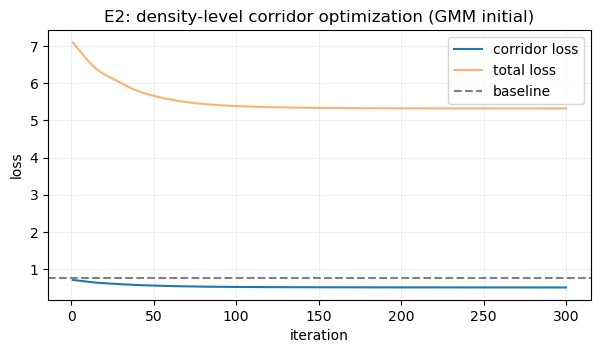

In [18]:
fig0, ax0 = plt.subplots(figsize=(7, 3.5))
ax0.plot([h["iter"] for h in history], [h["Lcorr"] for h in history], label="corridor loss")
ax0.plot([h["iter"] for h in history], [h["Ltotal"] for h in history], label="total loss", alpha=0.6)
ax0.axhline(L_base.item(), ls="--", color="0.5", label="baseline")
ax0.set_xlabel("iteration"); ax0.set_ylabel("loss")
ax0.set_title("E2: density-level corridor optimization (GMM initial)")
ax0.legend(); ax0.grid(alpha=0.2)
fig0.savefig(str(Path(FIGDIR) / "E2_loss.pdf"), dpi=200, bbox_inches="tight")
plt.show()

## Figure 2: Optimized protocol parameters

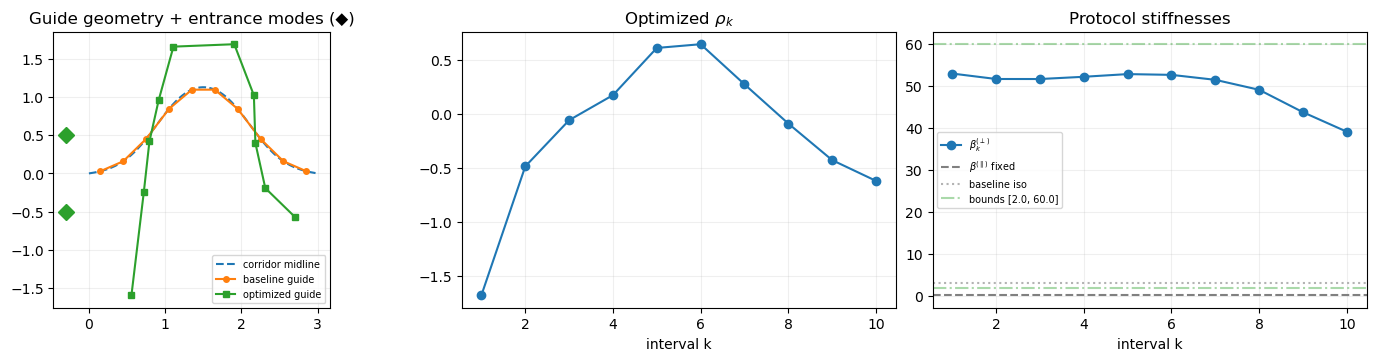

In [19]:
fig1, axes1 = plt.subplots(1, 3, figsize=(14, 3.5), constrained_layout=True)

corr_np = corridor["xy"].detach().cpu().numpy()
axes1[0].plot(corr_np[:, 0], corr_np[:, 1], "--", lw=1.5, label="corridor midline")
axes1[0].plot(aux_base["nu"].detach().cpu().numpy()[:, 0],
              aux_base["nu"].detach().cpu().numpy()[:, 1], "o-", ms=4, label="baseline guide")
axes1[0].plot(aux_opt["nu"].detach().cpu().numpy()[:, 0],
              aux_opt["nu"].detach().cpu().numpy()[:, 1], "s-", ms=4, label="optimized guide")
# Show entrance modes
for i in range(initial.M):
    mi = initial.means[i].detach().cpu().numpy()
    axes1[0].plot(mi[0], mi[1], "D", ms=8, color="C2", zorder=5)
axes1[0].set_title("Guide geometry + entrance modes (◆)")
axes1[0].legend(fontsize=7)
axes1[0].set_aspect("equal", adjustable="box"); axes1[0].grid(alpha=0.2)

kk = np.arange(1, K+1)
axes1[1].plot(kk, state.rho.detach().cpu().numpy(), "o-")
axes1[1].set_title(r"Optimized $\rho_k$"); axes1[1].set_xlabel("interval k"); axes1[1].grid(alpha=0.2)

axes1[2].plot(kk, c_beta_to_beta_perp(state.c_beta).detach().cpu().numpy(), "o-", label=r"$\beta_k^{(\perp)}$")
axes1[2].axhline(BETA_LONG_FIXED, ls="--", color="0.5", label=r"$\beta^{(\parallel)}$ fixed")
axes1[2].axhline(BETA_PERP_BASELINE, ls=":", color="0.7", label="baseline iso")
axes1[2].axhline(BETA_PERP_MIN, ls="-.", color="C2", alpha=0.4, label=f"bounds [{BETA_PERP_MIN}, {BETA_PERP_MAX}]")
axes1[2].axhline(BETA_PERP_MAX, ls="-.", color="C2", alpha=0.4)
axes1[2].set_title("Protocol stiffnesses"); axes1[2].set_xlabel("interval k")
axes1[2].legend(fontsize=7); axes1[2].grid(alpha=0.2)

fig1.savefig(str(Path(FIGDIR) / "E2_params.pdf"), dpi=200, bbox_inches="tight")
plt.show()

## Run EM simulations for visualization

We sample $B_{\mathrm{sim}}$ particles from $p^{(\mathrm{in})}$ and evolve
each one via Euler–Maruyama with the control conditioned on its own $x_0$.
This is done once per protocol (baseline and optimized).

In [20]:
print("Running EM simulation for baseline protocol...")
x0_sim = sample_from_marginal(
    {"weights": initial.weights, "means": initial.means, "covs": initial.covs},
    B_SIM, seed=SEED + 500,
).to(DTYPE).to(DEVICE)

em_times_base, em_traj_base = simulate_distributed(
    protocol_base, target, x0_sim, initial, n_steps=N_STEPS_EM, seed=SEED + 600)
print(f"  Done: {em_traj_base.shape[0]} steps, {em_traj_base.shape[1]} particles")

print("Running EM simulation for optimized protocol...")
em_times_opt, em_traj_opt = simulate_distributed(
    protocol_opt, target, x0_sim, initial, n_steps=N_STEPS_EM, seed=SEED + 600)
print(f"  Done: {em_traj_opt.shape[0]} steps, {em_traj_opt.shape[1]} particles")

Running EM simulation for baseline protocol...
  Done: 201 steps, 200 particles
Running EM simulation for optimized protocol...
  Done: 201 steps, 200 particles


## Figure 3: Baseline diagnostic triplet

- **Row 1:** EM-simulated particles (starting from $p^{(\mathrm{in})}$).
- **Row 2:** Analytical density contours (from the $B \times M_{\mathrm{tar}}$ GMM).
- **Row 3:** Particle-averaged drift field.

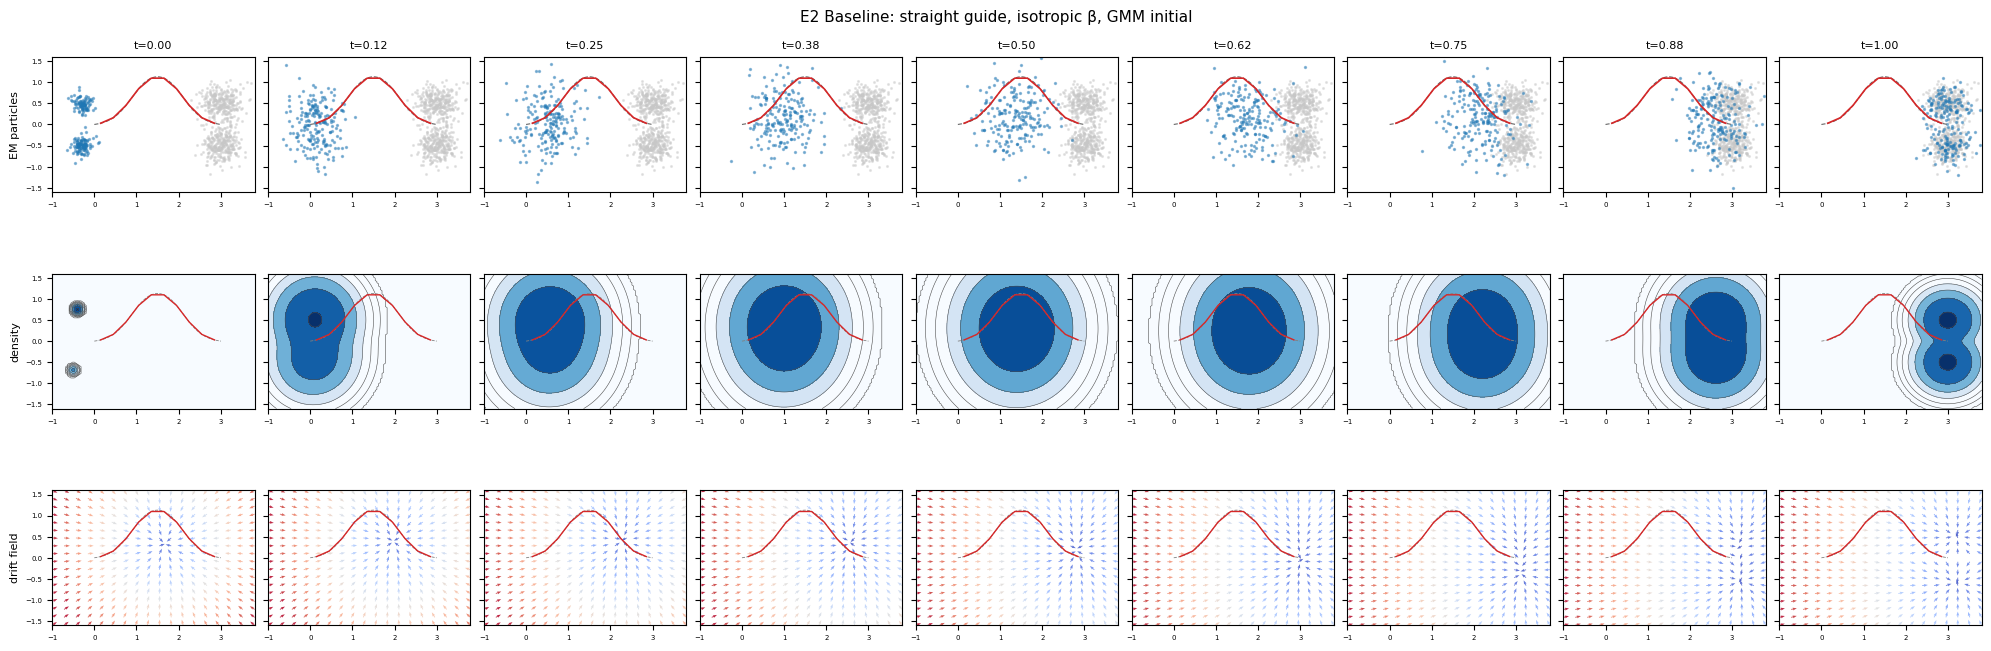

In [21]:
fig_base = plot_diagnostic_triplet(
    protocol_base, target, x0_samples, SNAPSHOT_TIMES,
    corridor_xy=corridor["xy"], guide_nu=aux_base["nu"],
    guide_tangent=aux_base["tangent"], guide_normal=aux_base["normal"],
    target_gmm=target, initial_gmm=initial,
    em_traj=em_traj_base, em_times=em_times_base,
    title_prefix="E2 Baseline: straight guide, isotropic β, GMM initial",
)
fig_base.savefig(str(Path(FIGDIR) / "E2_baseline_triplet.pdf"), dpi=200, bbox_inches="tight")
plt.show()

## Figure 4: Optimized diagnostic triplet

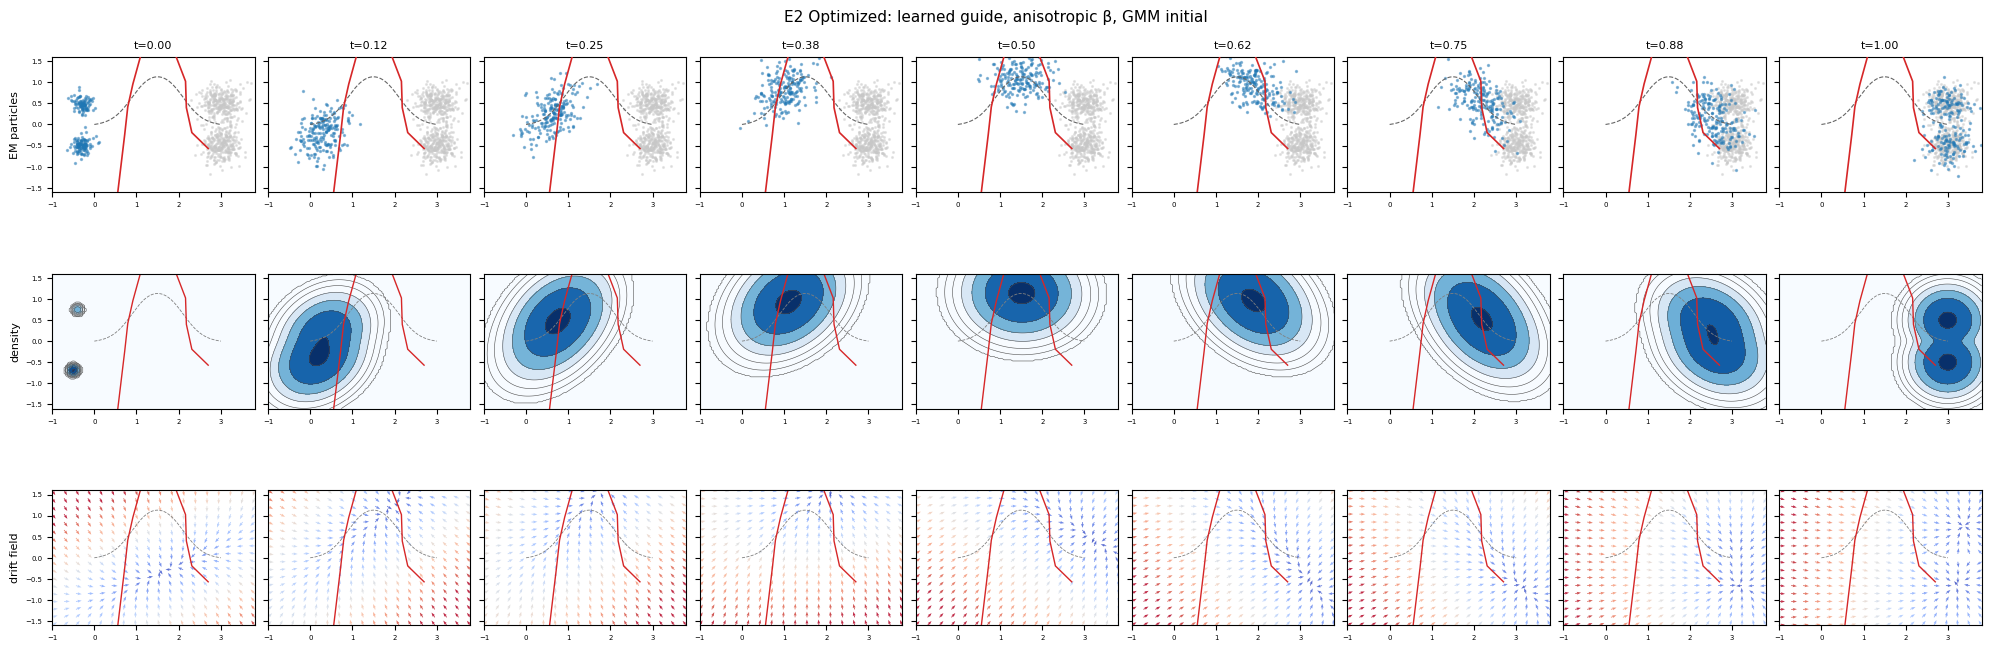

In [22]:
fig_opt = plot_diagnostic_triplet(
    protocol_opt, target, x0_samples, SNAPSHOT_TIMES,
    corridor_xy=corridor["xy"], guide_nu=aux_opt["nu"],
    guide_tangent=aux_opt["tangent"], guide_normal=aux_opt["normal"],
    target_gmm=target, initial_gmm=initial,
    em_traj=em_traj_opt, em_times=em_times_opt,
    title_prefix="E2 Optimized: learned guide, anisotropic β, GMM initial",
)
fig_opt.savefig(str(Path(FIGDIR) / "E2_optimized_triplet.pdf"), dpi=200, bbox_inches="tight")
plt.show()

## Figure 5: Side-by-side comparison (EM particles)

Row 1 = baseline EM particles, Row 2 = optimized EM particles.

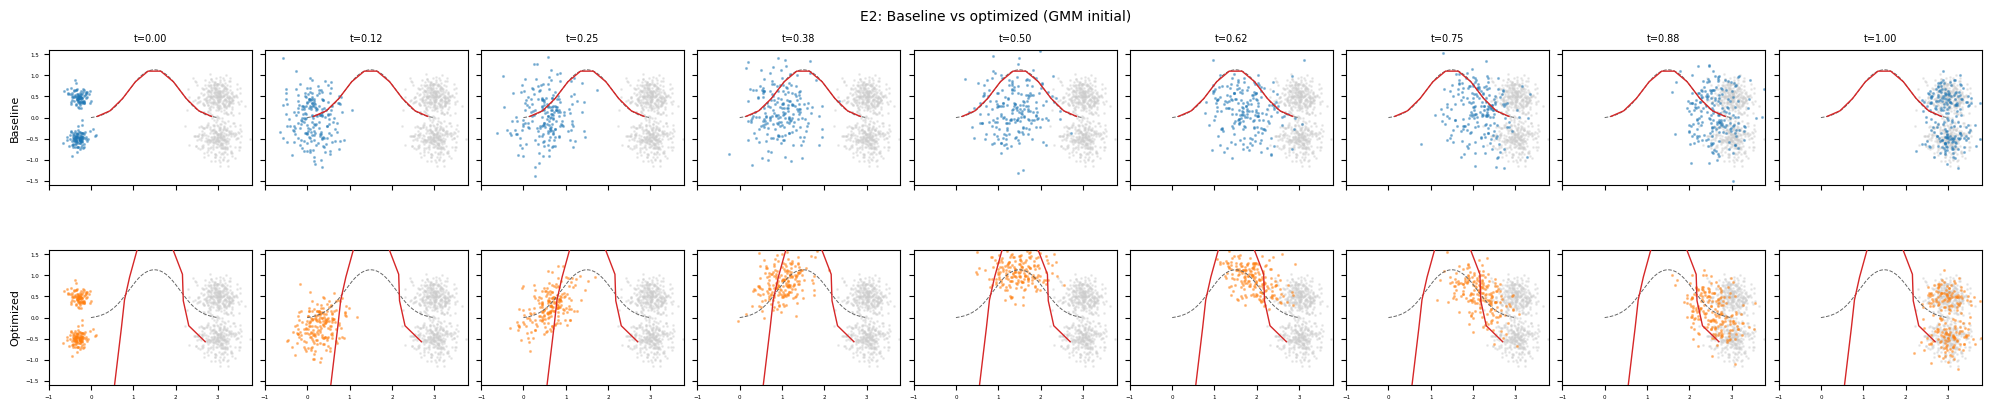

In [23]:
ncols = len(SNAPSHOT_TIMES)
fig5, axes5 = plt.subplots(2, ncols, figsize=(2.2 * ncols, 4.0), constrained_layout=True)
corr_np = corridor["xy"].detach().cpu().numpy()
tgt_samp = sample_from_marginal(
    {"weights": target.weights, "means": target.means, "covs": target.covs}, 600, seed=777).numpy()

_prev_grad = torch.is_grad_enabled()
torch.set_grad_enabled(False)
for row_idx, (prot_r, aux_r, em_tr, em_tm, label) in enumerate([
    (protocol_base, aux_base, em_traj_base, em_times_base, "Baseline"),
    (protocol_opt, aux_opt, em_traj_opt, em_times_opt, "Optimized"),
]):
    nu_np = aux_r["nu"].detach().cpu().numpy()
    for j, t_q in enumerate(SNAPSHOT_TIMES):
        ax = axes5[row_idx, j]
        t_eval = float(max(TD_EPS, min(t_q, 1.0 - TD_EPS)))
        idx_em = int(torch.argmin(torch.abs(em_tm - t_eval)).item())
        particles = em_tr[idx_em].detach().cpu().numpy()
        ax.scatter(tgt_samp[:, 0], tgt_samp[:, 1], s=1.0, c="0.80", alpha=0.35, zorder=1)
        color = "C0" if row_idx == 0 else "C1"
        ax.scatter(particles[:, 0], particles[:, 1], s=1.5, c=color, alpha=0.4, zorder=2)
        ax.plot(corr_np[:, 0], corr_np[:, 1], "--", color="0.4", lw=0.7, zorder=3)
        ax.plot(nu_np[:, 0], nu_np[:, 1], "-", color="C3", lw=1.0, zorder=4)
        ax.set_xlim(XLIM); ax.set_ylim(YLIM)
        ax.set_aspect("equal", adjustable="box"); ax.tick_params(labelsize=4)
        if j > 0: ax.set_yticklabels([])
        if row_idx == 0: ax.set_title(f"t={t_q:.2f}", fontsize=7); ax.set_xticklabels([])
    axes5[row_idx, 0].set_ylabel(label, fontsize=8)
torch.set_grad_enabled(_prev_grad)

fig5.suptitle("E2: Baseline vs optimized (GMM initial)", fontsize=10, y=1.02)
fig5.savefig(str(Path(FIGDIR) / "E2_comparison.pdf"), dpi=200, bbox_inches="tight")
plt.show()

## Figure 6: Entrance-merging zoom

Early-time detail ($t \in [0, 0.25]$) showing how the two entrance modes
funnel into the corridor under both protocols.

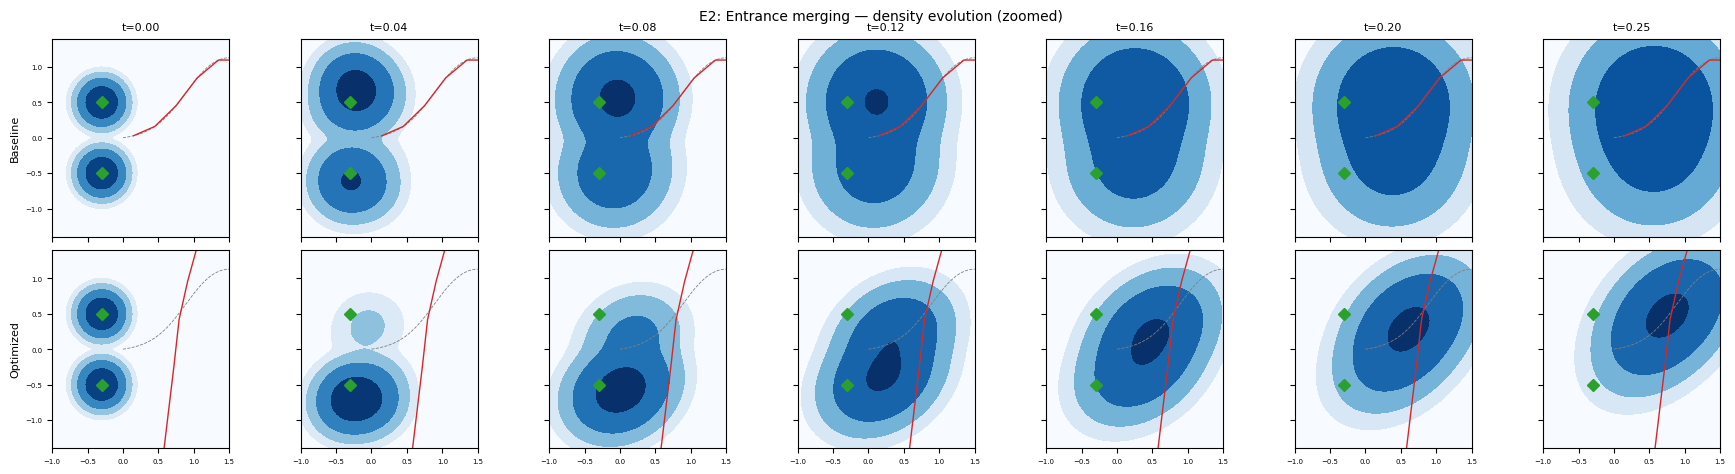

In [24]:
ncols_m = len(MERGE_TIMES)
fig6, axes6 = plt.subplots(2, ncols_m, figsize=(2.5 * ncols_m, 4.5), constrained_layout=True)

_prev_grad = torch.is_grad_enabled()
torch.set_grad_enabled(False)
for row_idx, (prot_r, aux_r, label) in enumerate([
    (protocol_base, aux_base, "Baseline"),
    (protocol_opt, aux_opt, "Optimized"),
]):
    nu_np = aux_r["nu"].detach().cpu().numpy()
    for j, t_q in enumerate(MERGE_TIMES):
        ax = axes6[row_idx, j]
        t_eval = float(max(TD_EPS, min(t_q, 1.0 - TD_EPS)))
        if t_q < 0.02:
            marg = {"weights": initial.weights, "means": initial.means, "covs": initial.covs}
        else:
            marg = marginal_from_samples(prot_r, target, x0_samples, t_eval)
        rho = eval_gmm_density(marg["weights"], marg["means"], marg["covs"],
                               *np.meshgrid(np.linspace(-1.0, 1.5, 100), np.linspace(-1.4, 1.4, 100)))
        Xz, Yz = np.meshgrid(np.linspace(-1.0, 1.5, 100), np.linspace(-1.4, 1.4, 100))
        rho_clip = np.clip(rho, 1e-6, None)
        ax.contourf(Xz, Yz, rho_clip, levels=12, cmap="Blues",
                    norm=LogNorm(vmin=1e-3, vmax=max(rho.max(), 1e-2)))
        ax.plot(corr_np[:, 0], corr_np[:, 1], "--", color="0.5", lw=0.6)
        ax.plot(nu_np[:, 0], nu_np[:, 1], "-", color="C3", lw=1.0)
        for i in range(initial.M):
            mi = initial.means[i].detach().cpu().numpy()
            ax.plot(mi[0], mi[1], "D", ms=6, color="C2", zorder=5)
        ax.set_xlim(-1.0, 1.5); ax.set_ylim(-1.4, 1.4)
        ax.set_aspect("equal", adjustable="box"); ax.tick_params(labelsize=5)
        if j > 0: ax.set_yticklabels([])
        if row_idx == 0: ax.set_title(f"t={t_q:.2f}", fontsize=8); ax.set_xticklabels([])
    axes6[row_idx, 0].set_ylabel(label, fontsize=8)
torch.set_grad_enabled(_prev_grad)

fig6.suptitle("E2: Entrance merging — density evolution (zoomed)", fontsize=10, y=1.02)
fig6.savefig(str(Path(FIGDIR) / "E2_entrance_merging.pdf"), dpi=200, bbox_inches="tight")
plt.show()

## Summary metrics

In [25]:
with torch.no_grad():
    marg_base_T = marginal_from_samples(protocol_base, target, x0_samples, 1.0 - TD_EPS)
    marg_opt_T = marginal_from_samples(protocol_opt, target, x0_samples, 1.0 - TD_EPS)

def gmm_mean_cov(marg):
    w = marg["weights"].detach()
    m = marg["means"].detach()
    c = marg["covs"].detach()
    mu = (w.unsqueeze(-1) * m).sum(0)
    S = sum(w[k] * (c[k] + torch.outer(m[k], m[k])) for k in range(w.numel())) - torch.outer(mu, mu)
    return mu, S

mu_base, cov_base = gmm_mean_cov(marg_base_T)
mu_opt, cov_opt = gmm_mean_cov(marg_opt_T)
mu_tgt = (target.weights.unsqueeze(-1) * target.means).sum(0)
cov_tgt = sum(target.weights[k] * (target.covs[k] + torch.outer(target.means[k], target.means[k]))
              for k in range(target.M)) - torch.outer(mu_tgt, mu_tgt)

summary = {
    "baseline_Lcorr": L_base.item(),
    "optimized_Lcorr": L_opt.item(),
    "improvement_pct": 100 * (L_base.item() - L_opt.item()) / L_base.item(),
    "baseline_mean_err": (mu_base - mu_tgt).norm().item(),
    "optimized_mean_err": (mu_opt - mu_tgt).norm().item(),
    "baseline_cov_err": (cov_base - cov_tgt).norm().item(),
    "optimized_cov_err": (cov_opt - cov_tgt).norm().item(),
    "best_iter": best["iter"],
    "n_marginal_components": B_INIT * target.M,
    "initial_modes": initial.M,
    "initial_particles": B_INIT,
    "target_modes": target.M,
}
for k, v in summary.items():
    print(f"{k:>25s}: {v:.4f}" if isinstance(v, float) else f"{k:>25s}: {v}")

save_metrics_json(str(Path(OUTDIR) / "metrics.json"), summary)

           baseline_Lcorr: 0.7733
          optimized_Lcorr: 0.5074
          improvement_pct: 34.3858
        baseline_mean_err: 0.0033
       optimized_mean_err: 0.0041
         baseline_cov_err: 0.0008
        optimized_cov_err: 0.0025
                best_iter: 300
    n_marginal_components: 120
            initial_modes: 2
        initial_particles: 60
             target_modes: 2
